<a href="https://colab.research.google.com/github/Mohamedfathi3060/DL-AI46-SV/blob/main/Copy_of_Dl_Lab3_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [ ]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# --- Transform ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

val_size = 5000
train_size = len(full_train_data) - val_size

train_data, val_data = random_split(full_train_data, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),            # (32*32*3 → 3072)

            nn.Linear(3072, 1024),
            nn.ReLU(),

            nn.Linear(1024, 512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
device

'cuda'

In [ ]:
for epoch in range(5):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

Epoch 1: loss = 1.3606
Epoch 2: loss = 1.7683
Epoch 3: loss = 1.8238
Epoch 4: loss = 1.6194
Epoch 5: loss = 1.0764


In [ ]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Accuracy:", correct / total)

Accuracy: 0.5255


In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),            # (32*32*3 → 3072)

            nn.Linear(4096, 1024),
            nn.ReLU(),

            nn.Linear(1024, 512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN().to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
device

'cuda'

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}  Loss: {epoch_loss:.4f}")

Epoch 1/10  Loss: 1.3402
Epoch 2/10  Loss: 0.8988
Epoch 3/10  Loss: 0.6613
Epoch 4/10  Loss: 0.4533
Epoch 5/10  Loss: 0.2644
Epoch 6/10  Loss: 0.1566
Epoch 7/10  Loss: 0.1034
Epoch 8/10  Loss: 0.0846
Epoch 9/10  Loss: 0.0720
Epoch 10/10  Loss: 0.0612


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 72.31%


## Transfer Learning Scenarios

In [ ]:
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs} Train Loss: {epoch_loss:.4f}")

        # --- Validation Step ---
        model.eval() # Set model to evaluation mode
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_accuracy = 100 * correct / total
        val_epoch_loss = val_loss / len(val_loader)
        print(f"Epoch {epoch+1}/{num_epochs} Val Loss: {val_epoch_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")
        model.train() # Set model back to training mode

def evaluate_model(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

### 3-A. Just Classification FC Layers

In [ ]:
print("\n --- Training only the final classification layer ---")
# here we just change the last FC to  match out problem
model_A = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_A.parameters():
    param.requires_grad = False

num_ftrs = model_A.fc.in_features
model_A.fc = nn.Linear(num_ftrs, 10)
model_A = model_A.to(device)

criterion_A = nn.CrossEntropyLoss()
optimizer_A = optim.Adam(model_A.fc.parameters(), lr=0.001)

num_epochs_A = 5
train_model(model_A, train_loader, val_loader, criterion_A, optimizer_A, device, num_epochs_A)

print("Evaluating Scenario 3-A model on Test Data:")
test_accuracy_A = evaluate_model(model_A, test_loader, device)
print(f"Test Accuracy: {test_accuracy_A:.2f}%")

print("Evaluating Scenario 3-A model on Validation Data:")
val_accuracy_A = evaluate_model(model_A, val_loader, device)
print(f"Validation Accuracy: {val_accuracy_A:.2f}%")


 --- Training only the final classification layer ---
Epoch 1/5 Train Loss: 1.7490
Epoch 1/5 Val Loss: 1.5946, Val Accuracy: 43.62%
Epoch 2/5 Train Loss: 1.6089
Epoch 2/5 Val Loss: 1.5404, Val Accuracy: 45.84%
Epoch 3/5 Train Loss: 1.5812
Epoch 3/5 Val Loss: 1.5689, Val Accuracy: 45.08%
Epoch 4/5 Train Loss: 1.5748
Epoch 4/5 Val Loss: 1.5413, Val Accuracy: 45.98%
Epoch 5/5 Train Loss: 1.5740
Epoch 5/5 Val Loss: 1.5820, Val Accuracy: 43.94%
Evaluating Scenario 3-A model on Test Data:
Test Accuracy: 44.46%
Evaluating Scenario 3-A model on Validation Data:
Validation Accuracy: 43.94%


### Finetune the final layers (responsible for high-level features extraction)

In [ ]:
print("\n---Finetuning final feature extraction layers and classification layers ---")

# here we allow some fine tune number of layers
model_B = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for name, param in model_B.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs_B = model_B.fc.in_features
model_B.fc = nn.Linear(num_ftrs_B, 10)
model_B = model_B.to(device)

criterion_B = nn.CrossEntropyLoss()
optimizer_B = optim.Adam(filter(lambda p: p.requires_grad, model_B.parameters()), lr=0.0001)

num_epochs_B = 5
train_model(model_B, train_loader, val_loader, criterion_B, optimizer_B, device, num_epochs_B)

print("Evaluating Scenario 3-B model on Test Data:")
test_accuracy_B = evaluate_model(model_B, test_loader, device)
print(f"Test Accuracy: {test_accuracy_B:.2f}%")

print("Evaluating Scenario 3-B model on Validation Data:")
val_accuracy_B = evaluate_model(model_B, val_loader, device)
print(f"Validation Accuracy: {val_accuracy_B:.2f}%")


---Finetuning final feature extraction layers and classification layers ---
Epoch 1/5 Train Loss: 1.3137
Epoch 1/5 Val Loss: 1.0739, Val Accuracy: 62.34%
Epoch 2/5 Train Loss: 0.9250
Epoch 2/5 Val Loss: 0.9863, Val Accuracy: 65.44%
Epoch 3/5 Train Loss: 0.7577
Epoch 3/5 Val Loss: 0.9585, Val Accuracy: 66.64%
Epoch 4/5 Train Loss: 0.6177
Epoch 4/5 Val Loss: 0.9862, Val Accuracy: 67.50%
Epoch 5/5 Train Loss: 0.5017
Epoch 5/5 Val Loss: 1.0520, Val Accuracy: 67.60%
Evaluating Scenario 3-B model on Test Data:
Test Accuracy: 67.10%
Evaluating Scenario 3-B model on Validation Data:
Validation Accuracy: 67.60%


### Finetune the whole model parameters

In [ ]:
print("\n--- Finetuning the entire model ---")

# now the Fukll fine tune, we will change (learn all weights) not freeze any thing
model_C = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# no freezw
for param in model_C.parameters():
    param.requires_grad = True

num_ftrs_C = model_C.fc.in_features
model_C.fc = nn.Linear(num_ftrs_C, 10)

model_C = model_C.to(device)

# Adam & loss
criterion_C = nn.CrossEntropyLoss()
optimizer_C = optim.Adam(model_C.parameters(), lr=0.0005) # more smaller LR as we in Fine turning


--- Finetuning the entire model ---


In [ ]:
# Train the model
num_epochs_C = 5
train_model(model_C, train_loader, val_loader, criterion_C, optimizer_C, device, num_epochs_C)

# Evaluate the model
print("Evaluating Scenario 3-C model on Test Data:")
test_accuracy_C = evaluate_model(model_C, test_loader, device)
print(f"Test Accuracy: {test_accuracy_C:.2f}%")

print("Evaluating Scenario 3-C model on Validation Data:")
val_accuracy_C = evaluate_model(model_C, val_loader, device)
print(f"Validation Accuracy: {val_accuracy_C:.2f}%")

Epoch 1/5 Train Loss: 0.8993
Epoch 1/5 Val Loss: 0.6672, Val Accuracy: 77.46%
Epoch 2/5 Train Loss: 0.5871
Epoch 2/5 Val Loss: 0.6281, Val Accuracy: 78.38%
Epoch 3/5 Train Loss: 0.4492
Epoch 3/5 Val Loss: 0.5830, Val Accuracy: 80.46%
Epoch 4/5 Train Loss: 0.3501
Epoch 4/5 Val Loss: 0.6393, Val Accuracy: 79.24%
Epoch 5/5 Train Loss: 0.2760
Epoch 5/5 Val Loss: 0.6481, Val Accuracy: 79.46%
Evaluating Scenario 3-C model on Test Data:
Test Accuracy: 79.45%
Evaluating Scenario 3-C model on Validation Data:
Validation Accuracy: 79.46%


### 4. Show some random filters before and after training

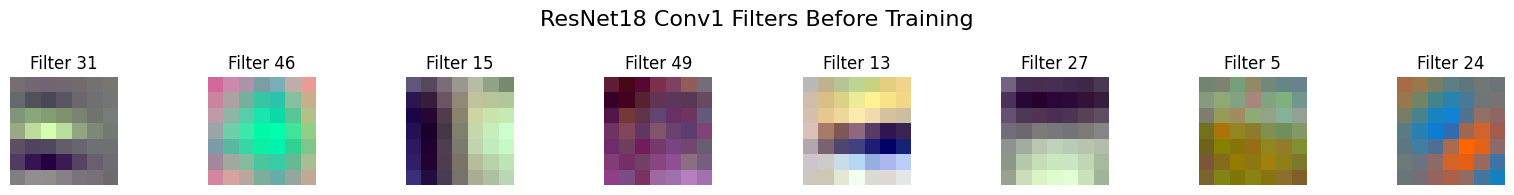

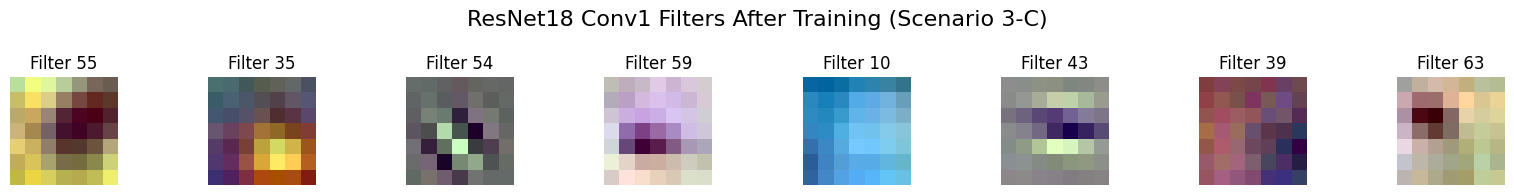

In [ ]:
def visualize_filters(model, layer_name='conv1', num_filters=8, title="Filters"):
    if not hasattr(model, layer_name):
        print(f"Layer '{layer_name}' not found in the model.")
        return

    layer = getattr(model, layer_name)
    if not isinstance(layer, nn.Conv2d):
        print(f"Layer '{layer_name}' is not a Conv2d layer.")
        return

    weights = layer.weight.data.cpu()

    num_output_channels = weights.shape[0]
    if num_filters > num_output_channels:
        num_filters = num_output_channels

    random_indices = np.random.choice(num_output_channels, num_filters, replace=False)

    fig, axes = plt.subplots(1, num_filters, figsize=(2 * num_filters, 2))
    fig.suptitle(title, fontsize=16)

    for i, idx in enumerate(random_indices):
        ax = axes[i]
        filter_img = weights[idx, :3, :, :]
        filter_img = filter_img.permute(1, 2, 0)
        filter_img = (filter_img - filter_img.min()) / (filter_img.max() - filter_img.min() + 1e-8)
        ax.imshow(filter_img)
        ax.axis('off')
        ax.set_title(f'Filter {idx+1}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

model_before_training = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
visualize_filters(model_before_training, layer_name='conv1', num_filters=8, title='ResNet18 Conv1 Filters Before Training')
visualize_filters(model_C, layer_name='conv1', num_filters=8, title='ResNet18 Conv1 Filters After Training (Scenario 3-C)')

### 5. Visualize Feature Maps

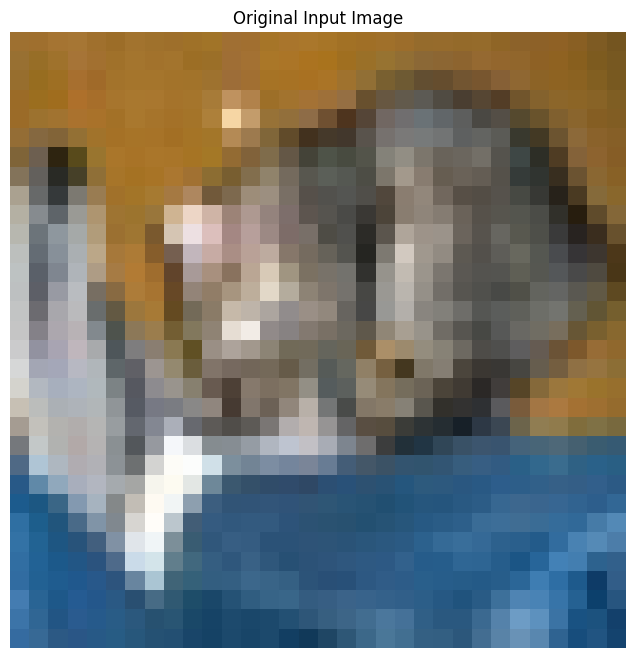

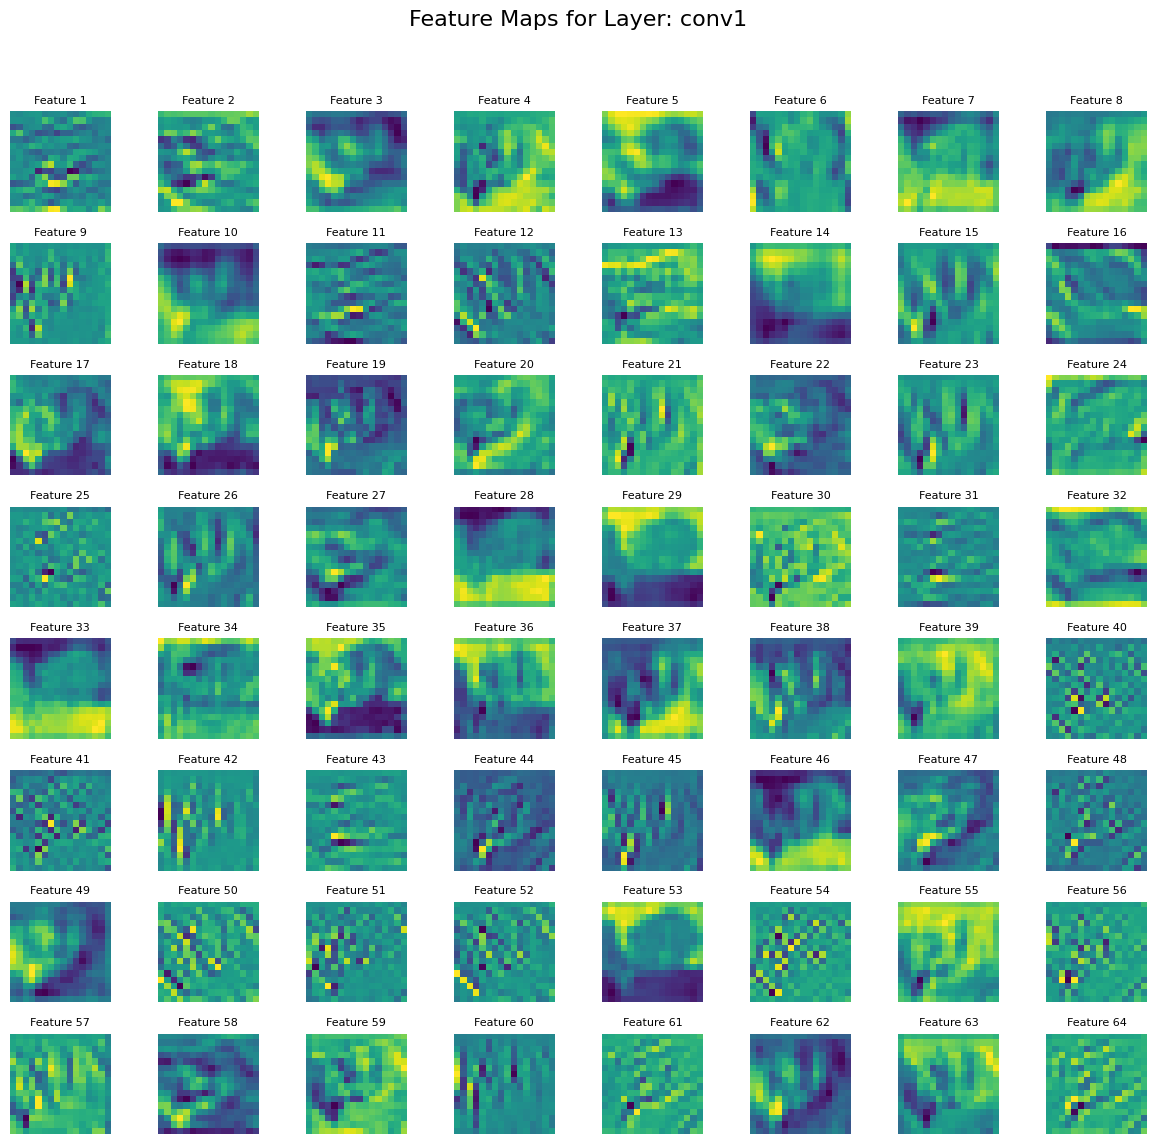

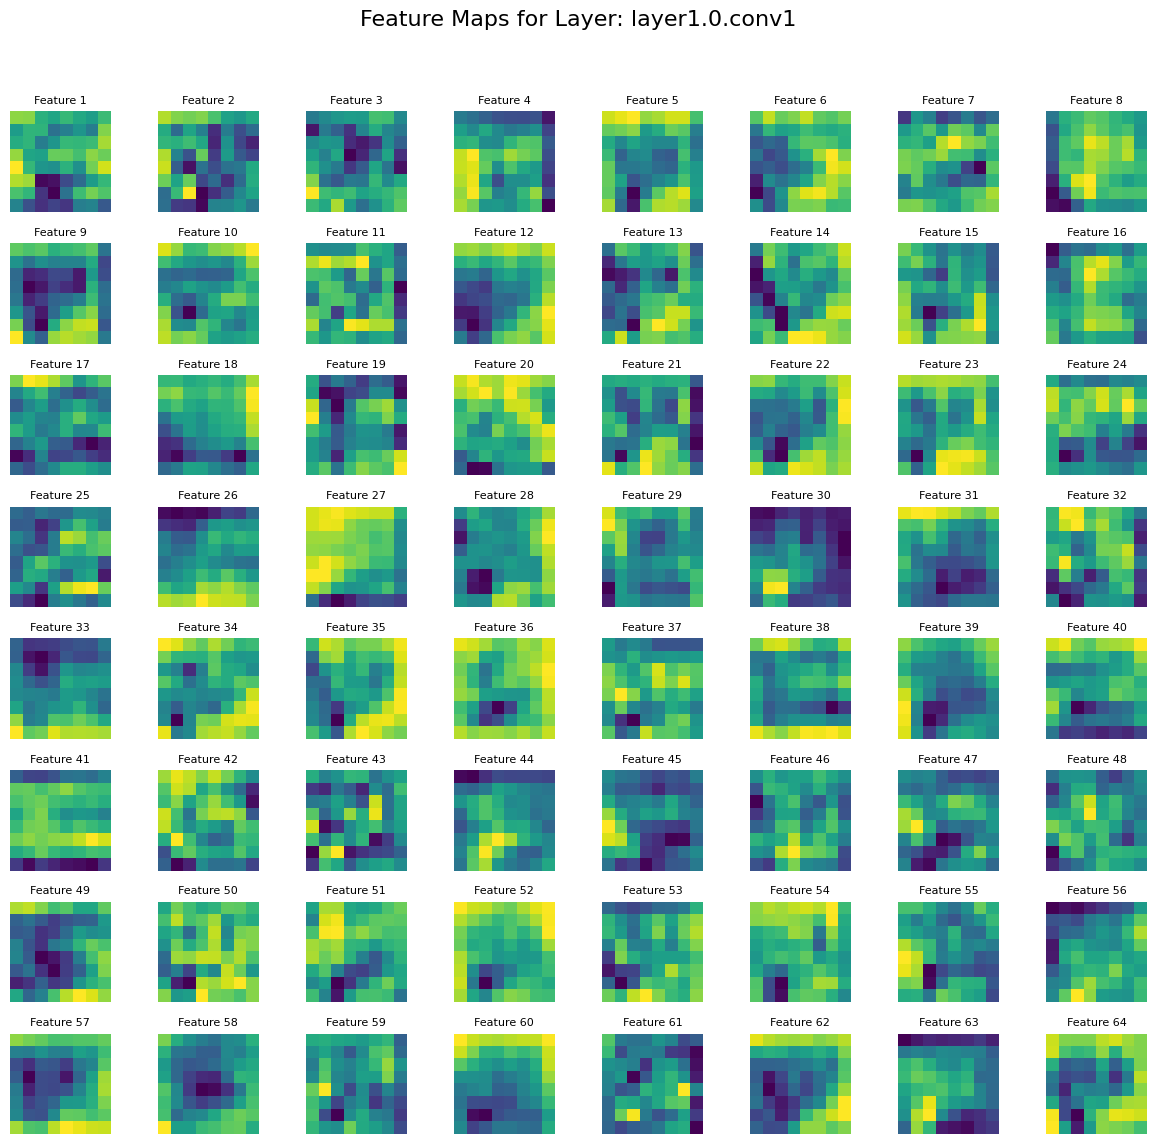

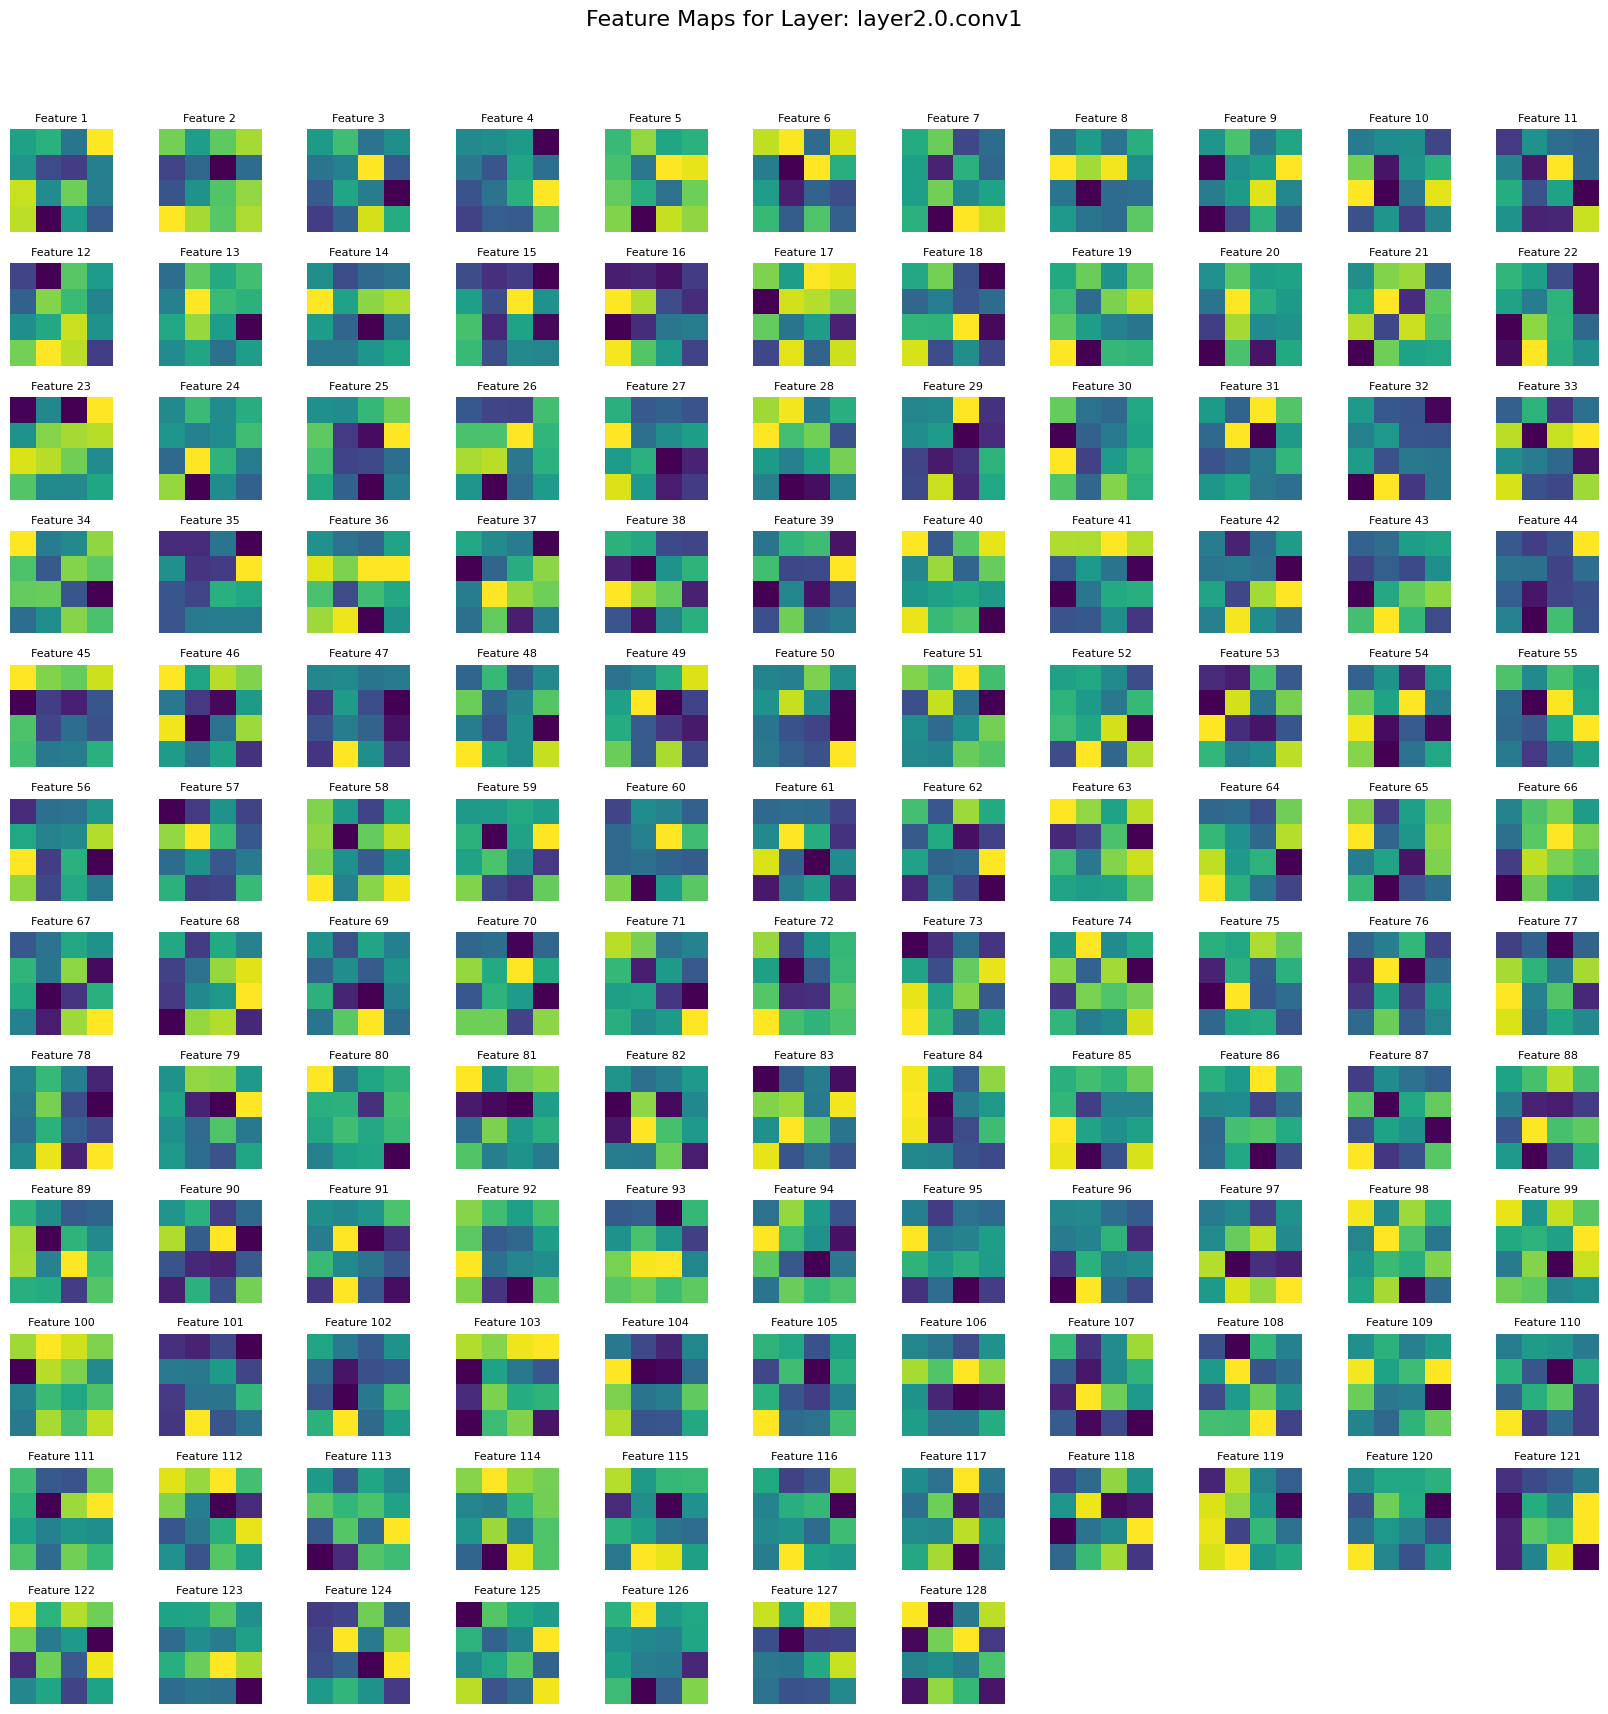

In [ ]:
# function to plot the image across many layers to show the features map (i search on it) (not Mine)

def visualize_feature_maps(model, img, layer_names):
    model.eval()
    feature_maps = {}
    hooks = []

    def get_activation(name):
        def hook(model, input, output):
            feature_maps[name] = output.detach()
        return hook

    for name, layer in model.named_modules():
        if name in layer_names:
            hooks.append(layer.register_forward_hook(get_activation(name)))

    img = img.to(device).unsqueeze(0)

    with torch.no_grad():
        _ = model(img)

    for layer_name in layer_names:
        if layer_name in feature_maps:
            fmap = feature_maps[layer_name].squeeze(0).cpu().numpy()

            num_features = fmap.shape[0]
            num_rows = int(np.ceil(np.sqrt(num_features)))
            num_cols = int(np.ceil(num_features / num_rows))

            fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 1.5, num_rows * 1.5))
            fig.suptitle(f'Feature Maps for Layer: {layer_name}', fontsize=16)
            axes = axes.flatten()

            for i in range(num_features):
                ax = axes[i]
                ax.imshow(fmap[i], cmap='viridis')
                ax.axis('off')
                ax.set_title(f'Feature {i+1}', fontsize=8)

            for i in range(num_features, len(axes)):
                fig.delaxes(axes[i])

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()
        else:
            print(f"Feature map for layer '{layer_name}' not found.")
    for h in hooks:
        h.remove()

test_iter = iter(test_loader)
example_images, example_labels = next(test_iter)
example_image = example_images[0] # Take the first image


layers_to_visualize = ['conv1', 'layer1.0.conv1', 'layer2.0.conv1']

plt.figure(figsize=(8,8))
plt.imshow(example_image.permute(1,2,0).cpu() * 0.5 + 0.5)
plt.title("Original Input Image")
plt.axis('off')
plt.show()

visualize_feature_maps(model_C, example_image, layers_to_visualize)
